# Neuroglobe Analysis Notebook 🧠 📊

This notebook performs statistical analysis on neuronal projection data extracted by the Neuroglobe Miner.

## Objectives
1.  **Strength Analysis**: Identify the strongest projection targets (Mean across experiments).
2.  **Cortical Index**: Standardized strength (0-1) specifically for cortical areas.
3.  **Tailored Analysis**: Interactive plot for user-defined regions.
4.  **Variability**: Analyze inter-animal consistency using Coefficient of Variation (CV).
5.  **Lateralization**: Compare Ipsilateral vs Contralateral projections.
6.  **Correlations**: Analyze relationships between injection volume and projection strength.

---

In [13]:
import sys
import os
from pathlib import Path
import yaml
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# =========================================
# SETUP & CONFIGURATION
# =========================================

# 1. Add Project Root to Sys Path to import src modules
# Assumes notebook is in <PROJECT_ROOT>/analysis/
current_dir = Path(os.getcwd())
if current_dir.name == 'analysis':
    project_root = current_dir.parent
else:
    # Fallback if running from root
    project_root = current_dir

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

try:
    from src.definitions import PROJECT_ROOT, DATA_DIR, CONFIGS_DIR
    print(f"[INFO] Project Root detected: {PROJECT_ROOT}")
except ImportError:
    print("[ERROR] Could not import src.definitions. Please ensure you are running this notebook from the correct environment.")
    # Fallback for DATA_DIR if import fails
    DATA_DIR = project_root / "data"
    CONFIGS_DIR = project_root / "configs"

# 2. Load Mining Config to get current Seed
config_path = CONFIGS_DIR / "mining_config.yaml"
CURRENT_SEED = None

if config_path.exists():
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    CURRENT_SEED = config.get('experiment', {}).get('seed_acronym', None)
    print(f"[INFO] Current Pipeline Seed: {CURRENT_SEED}")
else:
    print("[WARN] Mining config not found. You may need to specify the file manually.")

# 3. Plotting Style
sns.set_theme(style="whitegrid", palette="muted")

[INFO] Project Root detected: C:\Projects python\Neuroglobe 4.0
[INFO] Current Pipeline Seed: ACA


## 1. Data Loading & Reference Export

**What we are doing:** 
1. Automatically finding the analysis CSV for the current seed (`{SEED}_full_analysis.csv`).
2. Generating a reference CSV (`region_reference.csv`) containing the full names of all analyzed regions for easy consultation.

**Note:** Unless specified otherwise, the analyses below aggregate data by calculating the **MEAN** across all available experiments.

In [14]:
ANALYSIS_DATA_DIR = PROJECT_ROOT / "analysis" / "data"
df = None

if CURRENT_SEED:
    target_filename = f"{CURRENT_SEED}_full_analysis.csv"
    target_file = ANALYSIS_DATA_DIR / target_filename
    
    if target_file.exists():
        print(f"[SUCCESS] Loading Analysis Data: {target_filename}")
        df = pd.read_csv(target_file)
        
        # Export Reference Table
        ref_table = df[['acronym', 'region_name']].drop_duplicates().sort_values('acronym')
        ref_path = ANALYSIS_DATA_DIR.parent / "region_reference.csv"
        ref_table.to_csv(ref_path, index=False)
        print(f"[INFO] Region reference saved to: {ref_path.name}")
        
        print(f"\nData loaded successfully! Records: {len(df)}")
        display(df.head())
    else:
        print(f"[kERROR] Analysis file not found: {target_file}")
        print(f"Did you run 'Miner Analysis' for seed {CURRENT_SEED}?")
else:
    print("[ERROR] No seed configured. Please check mining_config.yaml")

[SUCCESS] Loading Analysis Data: ACA_full_analysis.csv
[INFO] Region reference saved to: region_reference.csv

Data loaded successfully! Records: 261618


,experiment_id,acronym,region_name,hemisphere_id,target_hemisphere,lateralization,projection_density,projection_energy,projection_volume,volume,is_injection,gender,strain,injection_volume
0,278069982,VISam2/3,"Anteromedial visual area, layer 2/3",2,Right,Ipsilateral,0.000000,0.000000,0.000000e+00,0.114082,False,M,FVB.CD1(ICR),0.0525
1,278069982,csc,superior colliculus commissure,1,Left,Contralateral,0.000253,0.164931,3.884866e-06,0.015372,False,M,FVB.CD1(ICR),0.0525
2,278069982,SCzo,"Superior colliculus, zonal layer",3,Midline,Midline,0.000212,0.034679,8.427436e-05,0.398269,False,M,FVB.CD1(ICR),0.0525
3,278069982,LPO,Lateral preoptic area,1,Left,Contralateral,0.000021,0.002599,6.635232e-06,0.308687,False,M,FVB.CD1(ICR),0.0525
4,278069982,MPT,Medial pretectal area,1,Left,Contralateral,0.000010,0.000638,2.316364e-07,0.024138,False,M,FVB.CD1(ICR),0.0525


## 2. Global Projection Strength

**Question:** Which regions receive the strongest input from the seed?
**Metric:** Mean `projection_density` across all experiments.
**Visualization:** Bar chart of ALL targets. 
*   **Red**: Cerebral Cortex
*   **Grey**: Other Regions

C:\Users\David\AppData\Local\Temp\ipykernel_17944\800244561.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


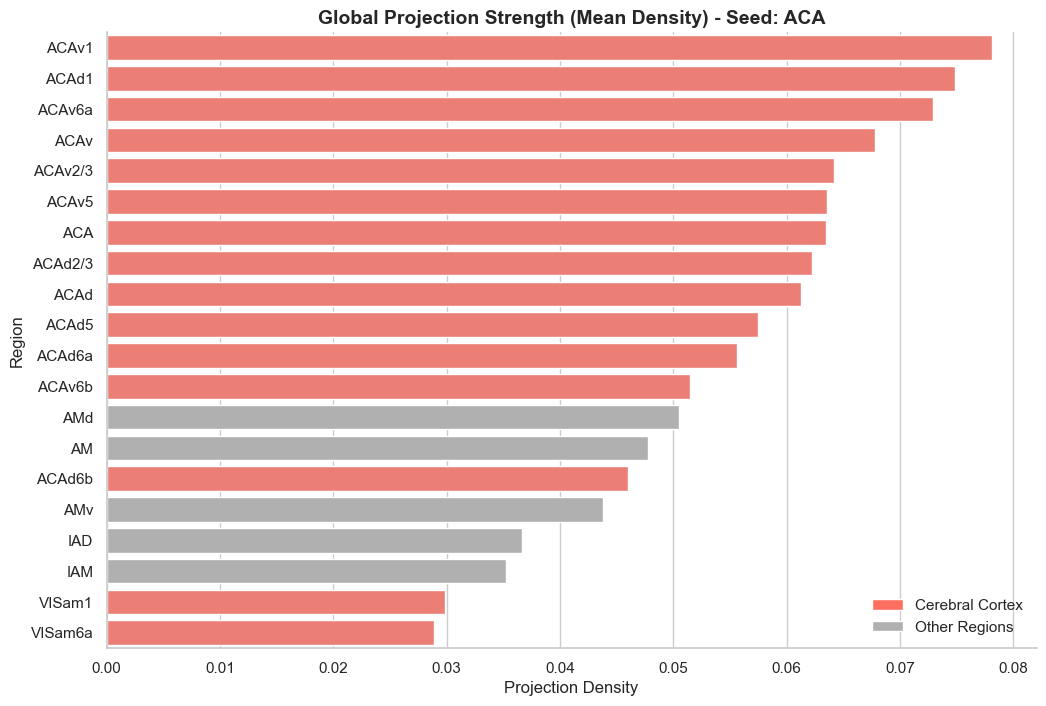

In [15]:
if df is not None:
    # Filter out the seed itself and aggregation structures
    clean_df = df[(df['is_injection'] == False) & (df['acronym'] != 'Isocortex')]

    # ======================
    # 1) FULL target_stats
    # ======================
    target_stats = (
        clean_df
        .groupby('acronym')
        .agg({
            'projection_density': 'mean',
            'region_name': 'first'
        })
        .sort_values(by='projection_density', ascending=False)
    )
    # target_stats now contains ALL regions, sorted by mean projection_density

    # ======================
    # 2) Color definition
    # ======================
    cortical_prefixes = [
        'MO', 'SS', 'VIS', 'AUD', 'RSP', 'ACA', 'PL',
        'ILA', 'ORB', 'AI', 'PTLp', 'TEa', 'PERI',
        'ECT', 'FRP'
    ]
    
    # Using a modern palette 'mako' for a sleek look, but overriding specific colors for cortex
    # Actually user asked for specific colors here before (Red/Grey). We keep that logic but refine shades.
    # Let's start with a modern base.

    def get_color(acro):
        # Modern Red for cortical
        for prefix in cortical_prefixes:
            if acro.startswith(prefix):
                return "#FF6F61"   # Living Coral (more modern red)
        # Modern Grey for others
        return "#B0B0B0"           # Neutral Grey

    # Colors for all regions
    all_colors = [get_color(acro) for acro in target_stats.index]

    # ======================
    # 3) TOP 20 for plotting
    # ======================
    top20 = target_stats.head(20)        # only the first 20 regions
    top20_colors = all_colors[:20]       # matching colors

    plt.figure(figsize=(12, 8))
    sns.barplot(
        x=top20['projection_density'],
        y=top20.index,
        palette=top20_colors
    )
    plt.title(f"Global Projection Strength (Mean Density) - Seed: {CURRENT_SEED}", fontsize=14, weight='bold')
    plt.xlabel("Projection Density", fontsize=12)
    plt.ylabel("Region", fontsize=12)

    # Legend (red vs grey)
    legend_elements = [
        Patch(facecolor="#FF6F61", label="Cerebral Cortex"),
        Patch(facecolor="#B0B0B0", label="Other Regions"),
    ]
    plt.legend(handles=legend_elements, frameon=False)
    sns.despine()

    plt.show()

## 3. Cortical Connectivity Index (0-1)

**Objective:** Focus exclusively on the Cortex and standardize the strength.
**Method:** 
1. Filter only cortical regions.
2. Calculate `Index = Density / Max_Density`.
3. The region with the highest density (e.g., layer IV of a specific area) will have Index = 1.0.

C:\Users\David\AppData\Local\Temp\ipykernel_17944\3486525827.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top100.values, y=top100.index, palette="magma") # Modern heatmap-like colors


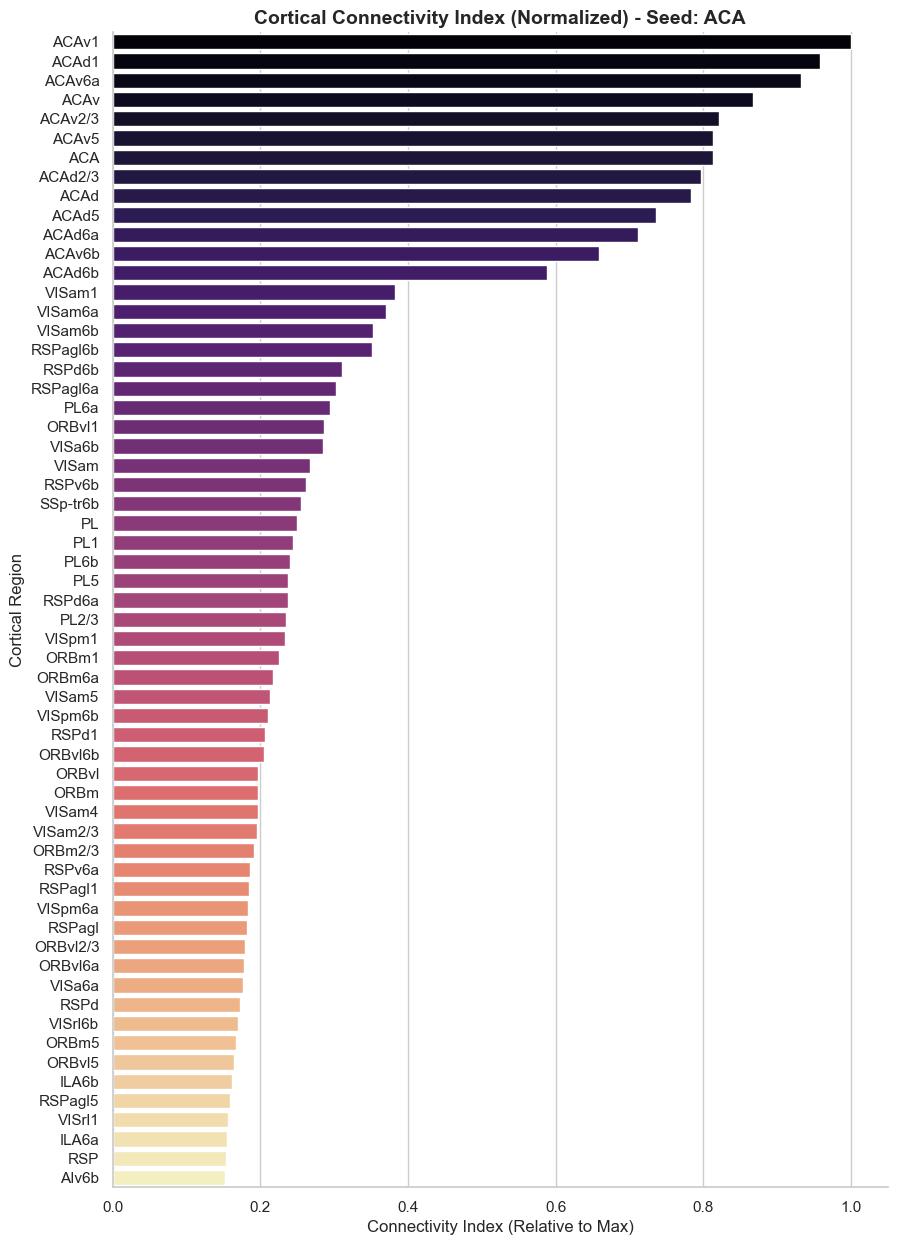

In [16]:
if df is not None:
    # 1. Filter Cortex
    is_cortex = clean_df['acronym'].apply(
        lambda x: any(x.startswith(p) for p in cortical_prefixes)
    )
    cortex_df = clean_df[is_cortex].copy()
    
    # 2. Calculate mean density per cortical region
    ctx_stats = cortex_df.groupby('acronym')['projection_density'].mean()
    
    # 3. Normalize (0–1) using the global max
    max_val = ctx_stats.max()
    ctx_index = (ctx_stats / max_val).sort_values(ascending=False)
    
    # 4. Keep only the top 100 regions for plotting
    top100 = ctx_index.head(60)
    
    # Plot using a modern sequential palette
    plt.figure(figsize=(10, max(5, len(top100) * 0.25)))
    sns.barplot(x=top100.values, y=top100.index, palette="magma") # Modern heatmap-like colors
    plt.title(f"Cortical Connectivity Index (Normalized) - Seed: {CURRENT_SEED}", fontsize=14, weight='bold')
    plt.xlabel("Connectivity Index (Relative to Max)", fontsize=12)
    plt.ylabel("Cortical Region", fontsize=12)
    plt.xlim(0, 1.05)
    sns.despine()
    plt.show()

## 4. Inter-Animal Variability Analysis

**Question:** Which projections are stable across animals and which are variable? **Metric:** Coefficient of Variation ($CV = \frac{\sigma}{\mu}$).

*   **Low CV:** Consistent projection (Stable).
*   **High CV:** Variable projection (Individual differences or noise).

**Plot:** Scatter Plot of **Mean Density (X)** vs **CV (Y)**.

*   **Bottom-Right:** Strong & Stable (The "Core" targets).
*   **Top-Left:** Weak & Variable (Noise or rare targets).

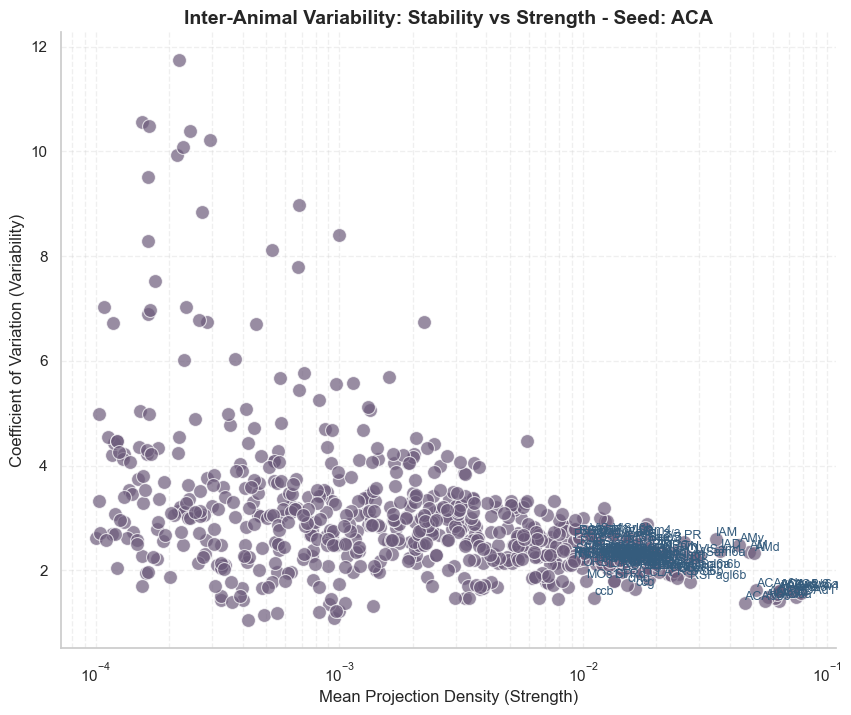

In [17]:
if df is not None:
    # Calculate Mean and Std for each region
    var_stats = clean_df.groupby('acronym')['projection_density'].agg(['mean', 'std'])

    # Calculate CV (Coefficient of Variation)
    # Add small epsilon to avoid division by zero if mean is 0
    var_stats['cv'] = var_stats['std'] / (var_stats['mean'] + 1e-9)

    # Filter out very low density noise for clearer plot
    plot_data = var_stats[var_stats['mean'] > 0.0001]

    plt.figure(figsize=(10, 8))
    # Use specific modern color
    sns.scatterplot(data=plot_data, x='mean', y='cv', alpha=0.7, s=100, color='#6C5B7B')

    # Annotate top stable regions (High Mean, Low CV)
    stable_core = plot_data[(plot_data['mean'] > plot_data['mean'].quantile(0.8)) & 
                            (plot_data['cv'] < plot_data['cv'].quantile(0.5))]

    for acro in stable_core.index:
        plt.text(stable_core.loc[acro, 'mean'], stable_core.loc[acro, 'cv'], 
                 acro, fontsize=9, ha='left', va='bottom', color='#355C7D')

    plt.title(f"Inter-Animal Variability: Stability vs Strength - Seed: {CURRENT_SEED}", fontsize=14, weight='bold')
    plt.xlabel("Mean Projection Density (Strength)", fontsize=12)
    plt.ylabel("Coefficient of Variation (Variability)", fontsize=12)
    plt.xscale('log') # Log scale for density often helps visualization
    plt.grid(True, which="both", ls="--", alpha=0.3)
    sns.despine()
    plt.show()

## 5. Lateralization Analysis

**Question:** Is the projection stronger on the Ipsilateral side (same as injection) vs Contralateral? **Method:** Boxplot comparing `projection_density` distributions for Ipsi vs Contra.

C:\Users\David\AppData\Local\Temp\ipykernel_17944\2286745938.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


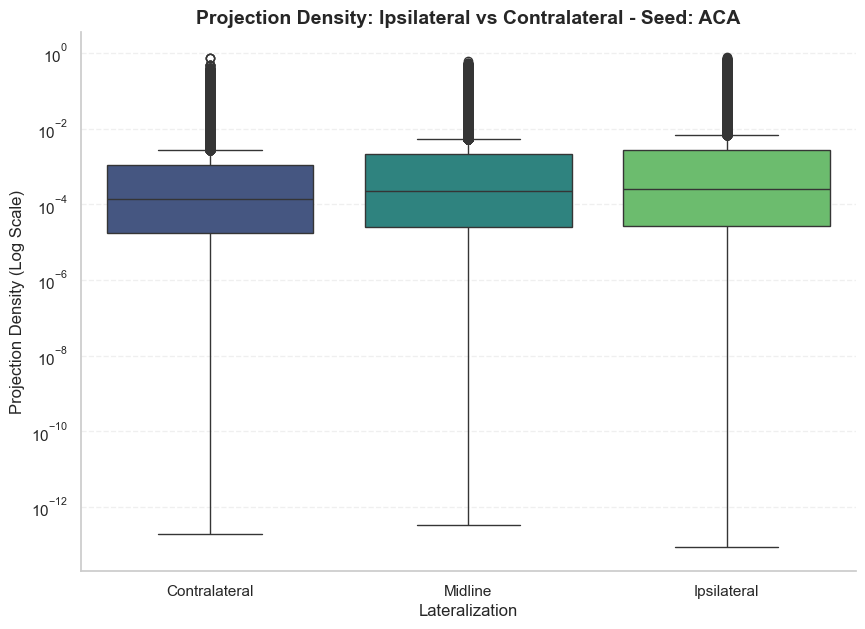

In [18]:
if df is not None:
    plt.figure(figsize=(10, 7))
    
    # Using a modern palette like 'viridis' or 'rocket' for better aesthetics
    # Autoscaling ensures the full 'candle' (whiskers/box) fits.
    # We filter out perfect zeros for log scale to avoid cluttering -infinity, 
    # though boxplot handles them by hiding or placing at bottom.
    # To ensure "full candle" fit, we let autoscaling do its work but ensure no manual limits clip it.
    
    plot_df = clean_df[clean_df['projection_density'] > 0] # Filter > 0 for proper log scaling
    
    sns.boxplot(
        data=plot_df, 
        x='lateralization', 
        y='projection_density', 
        palette="viridis"  # Modern color scheme
    )
    
    plt.yscale('log')
    plt.title(f"Projection Density: Ipsilateral vs Contralateral - Seed: {CURRENT_SEED}", fontsize=14, weight='bold')
    plt.ylabel("Projection Density (Log Scale)", fontsize=12)
    plt.xlabel("Lateralization", fontsize=12)
    
    # Ensure y-axis encompasses all data
    # Seaborn/Matplotlib usually autoscales, but filtering 0s helps log-scale autoscaler find the true min data point.
    sns.despine()
    plt.grid(True, axis='y', ls="--", alpha=0.3)
    plt.show()